# Full EDA: Synthetic Domestic Violence Dataset
## Phase 0 → Phase 11

A structured, end-to-end exploratory data analysis. Upload `synthetic_domestic_violence_dataset.csv` to Colab's file panel (or mount Drive) before running.

| Phase | Name |
|---|---|
| 0 | Setup & Data Loading |
| 1 | Data Structure Overview |
| 2 | Data Quality Checks |
| 3 | Summary Statistics |
| 4 | Univariate Analysis — Numeric |
| 5 | Univariate Analysis — Categorical |
| 6 | Bivariate Analysis — Numeric vs Numeric |
| 7 | Bivariate Analysis — Categorical vs Categorical |
| 8 | Bivariate Analysis — Numeric vs Categorical |
| 9 | Outlier Detection |
| 10 | Feature Engineering & Derived Insights |
| 11 | Key Findings & Final Summary |


## Phase 0 — Setup & Data Loading

In [ ]:
# from google.colab import files
# uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

df = pd.read_csv("synthetic_domestic_violence_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (1200, 15)


,case_id,victim_age,victim_gender,education_level,employment_status,marital_status,household_income,number_of_children,residence_type,violence_type,incident_frequency_per_year,reported_to_authorities,medical_assistance_required,support_services_used,perpetrator_relationship
0,1,49,Female,Primary,Employed,Widowed,14074,0,Rural,Emotional,14,No,Yes,No,Spouse
1,2,52,Male,Graduate,Self-employed,Separated,10870,1,Rural,Emotional,8,No,No,Yes,Partner
2,3,28,Male,Graduate,Self-employed,Divorced,28523,5,Rural,Economic,12,No,No,Yes,Spouse
3,4,27,Female,Postgraduate,Employed,Married,64474,6,Urban,Emotional,1,No,Yes,Yes,Spouse
4,5,61,Female,Postgraduate,Employed,Separated,6532,6,Rural,Sexual,18,No,No,No,Family Member


## Phase 1 — Data Structure Overview

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   case_id                      1200 non-null   int64 
 1   victim_age                   1200 non-null   int64 
 2   victim_gender                1200 non-null   object
 3   education_level              1200 non-null   object
 4   employment_status            1200 non-null   object
 5   marital_status               1200 non-null   object
 6   household_income             1200 non-null   int64 
 7   number_of_children           1200 non-null   int64 
 8   residence_type               1200 non-null   object
 9   violence_type                1200 non-null   object
 10  incident_frequency_per_year  1200 non-null   int64 
 11  reported_to_authorities      1200 non-null   object
 12  medical_assistance_required  1200 non-null   object
 13  support_services_used        1200

In [ ]:
num_cols = ['victim_age', 'household_income', 'number_of_children', 'incident_frequency_per_year']
cat_cols = [c for c in df.columns if c not in num_cols + ['case_id']]

print(f"Numeric columns ({len(num_cols)}):", num_cols)
print(f"\nCategorical columns ({len(cat_cols)}):", cat_cols)
print(f"\nID column: case_id")

Numeric columns (4): ['victim_age', 'household_income', 'number_of_children', 'incident_frequency_per_year']

Categorical columns (10): ['victim_gender', 'education_level', 'employment_status', 'marital_status', 'residence_type', 'violence_type', 'reported_to_authorities', 'medical_assistance_required', 'support_services_used', 'perpetrator_relationship']

ID column: case_id


## Phase 2 — Data Quality Checks
Missing values, duplicates, dtype consistency, and unexpected category values.

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(quality[quality['missing_count'] > 0] if missing.sum() > 0 else "No missing values found.")

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate case_ids:", df['case_id'].duplicated().sum())

No missing values found.

Duplicate rows: 0
Duplicate case_ids: 0


In [ ]:
# Sanity-check ranges
print("victim_age range:", df['victim_age'].min(), "-", df['victim_age'].max())
print("household_income range:", df['household_income'].min(), "-", df['household_income'].max())
print("number_of_children range:", df['number_of_children'].min(), "-", df['number_of_children'].max())
print("incident_frequency_per_year range:", df['incident_frequency_per_year'].min(), "-", df['incident_frequency_per_year'].max())

victim_age range: 18 - 65
household_income range: 5070 - 99932
number_of_children range: 0 - 6
incident_frequency_per_year range: 1 - 20


## Phase 3 — Summary Statistics

In [ ]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
victim_age,1200.0,41.865833,13.863910,18.0,30.0,43.0,54.00,65.0
household_income,1200.0,50845.645833,27398.104925,5070.0,27582.5,50293.5,73864.75,99932.0
number_of_children,1200.0,3.090833,2.027974,0.0,1.0,3.0,5.00,6.0
incident_frequency_per_year,1200.0,10.395833,5.731043,1.0,5.0,10.0,15.00,20.0


In [ ]:
for col in cat_cols:
    print(f"\n--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts())


--- victim_gender (3 unique) ---
victim_gender
Other     407
Male      400
Female    393
Name: count, dtype: int64

--- education_level (4 unique) ---
education_level
Postgraduate    323
Graduate        313
Secondary       287
Primary         277
Name: count, dtype: int64

--- employment_status (4 unique) ---
employment_status
Employed         305
Self-employed    302
Unemployed       300
Student          293
Name: count, dtype: int64

--- marital_status (4 unique) ---
marital_status
Divorced     320
Separated    302
Widowed      289
Married      289
Name: count, dtype: int64

--- residence_type (2 unique) ---
residence_type
Rural    624
Urban    576
Name: count, dtype: int64

--- violence_type (5 unique) ---
violence_type
Economic     249
Emotional    247
Physical     238
Multiple     237
Sexual       229
Name: count, dtype: int64

--- reported_to_authorities (2 unique) ---
reported_to_authorities
Yes    627
No     573
Name: count, dtype: int64

--- medical_assistance_required (2 uni

## Phase 4 — Univariate Analysis: Numeric Features

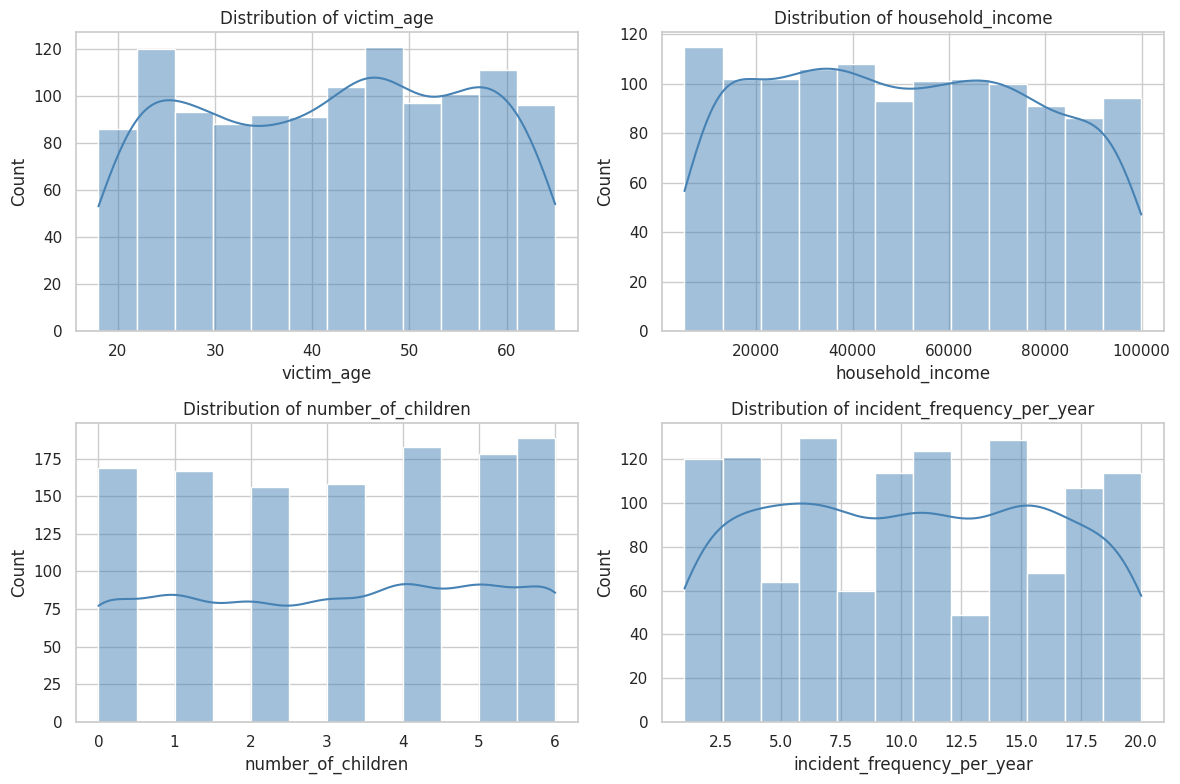

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout(); plt.show()

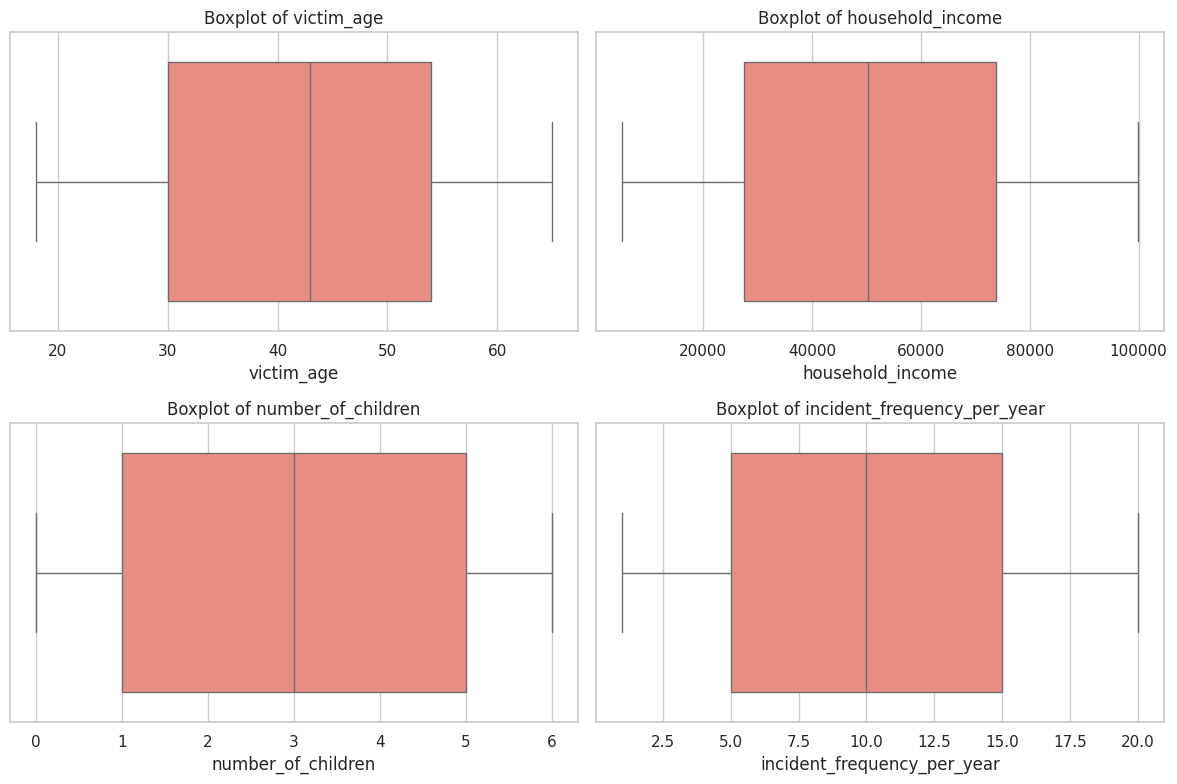

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=df[col], ax=ax, color='salmon')
    ax.set_title(f'Boxplot of {col}')
plt.tight_layout(); plt.show()

In [ ]:
skew_kurt = pd.DataFrame({
    'skewness': df[num_cols].skew(),
    'kurtosis': df[num_cols].kurtosis()
})
skew_kurt

,skewness,kurtosis
victim_age,-0.061942,-1.212205
household_income,0.071612,-1.176275
number_of_children,-0.069077,-1.279797
incident_frequency_per_year,0.019775,-1.202701


## Phase 5 — Univariate Analysis: Categorical Features

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(14, 22))
for ax, col in zip(axes.flatten(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, palette='viridis')
    ax.set_title(col)
plt.tight_layout(); plt.show()

/tmp/ipykernel_5807/2018030141.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=ax, palette='viridis')
/tmp/ipykernel_5807/2018030141.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=ax, palette='viridis')
/tmp/ipykernel_5807/2018030141.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=ax, palette='viridis')
/tmp/ipykernel_5807/2018030141.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. 

## Phase 6 — Bivariate Analysis: Numeric vs Numeric

In [ ]:
corr = df[num_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation matrix (numeric features)")
plt.show()
corr

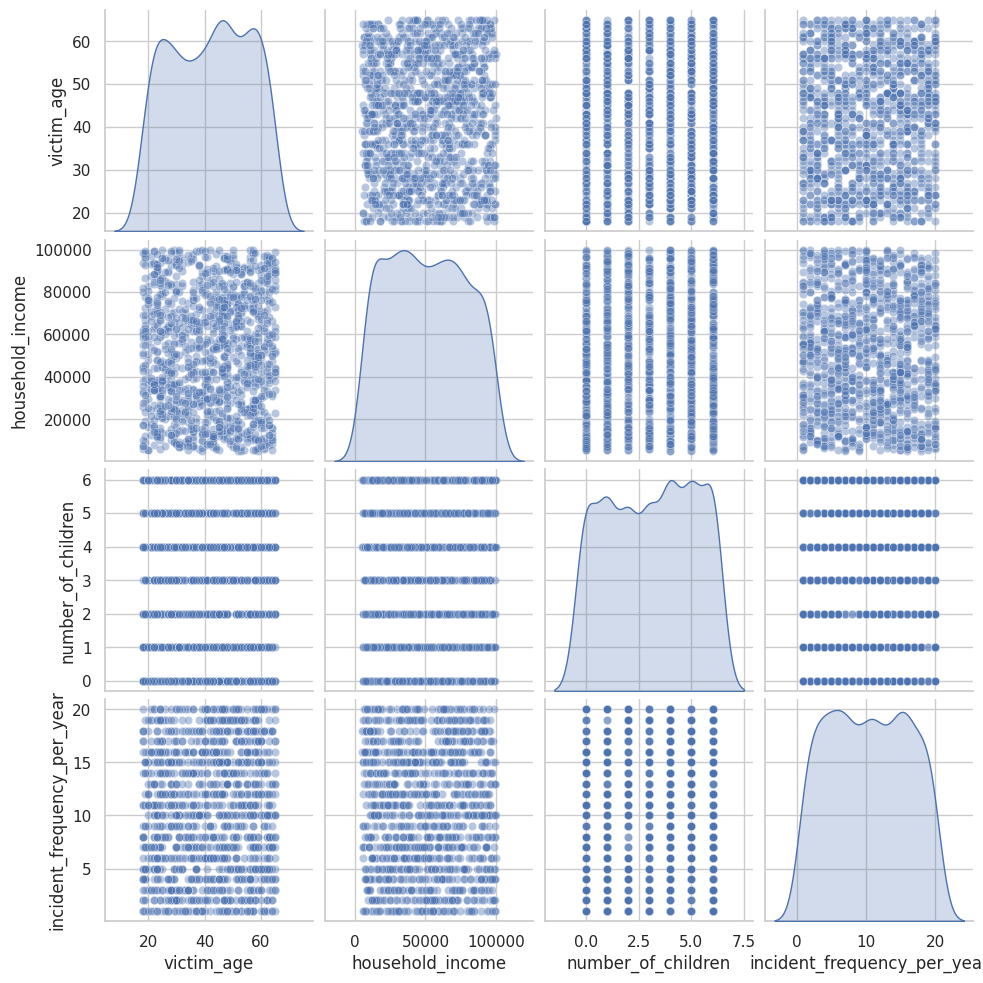

In [ ]:
sns.pairplot(df[num_cols], diag_kind='kde', plot_kws={'alpha':0.4})
plt.show()

## Phase 7 — Bivariate Analysis: Categorical vs Categorical

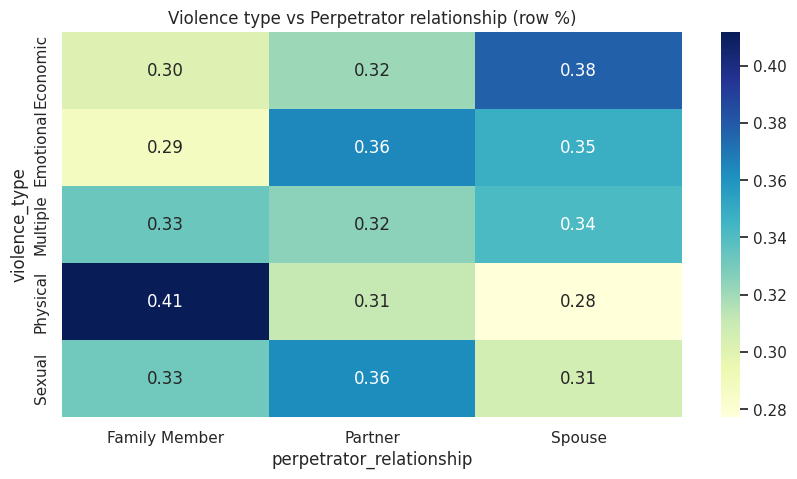

In [ ]:
ct1 = pd.crosstab(df['violence_type'], df['perpetrator_relationship'], normalize='index')
plt.figure(figsize=(10, 5))
sns.heatmap(ct1, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title("Violence type vs Perpetrator relationship (row %)")
plt.show()

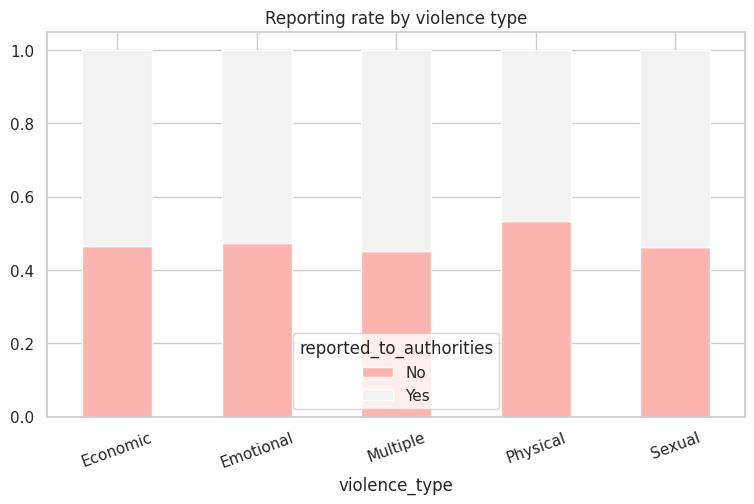

reported_to_authorities,No,Yes
violence_type,,
Economic,0.465863,0.534137
Emotional,0.473684,0.526316
Multiple,0.451477,0.548523
Physical,0.533613,0.466387
Sexual,0.462882,0.537118


In [ ]:
ct2 = pd.crosstab(df['violence_type'], df['reported_to_authorities'], normalize='index')
ct2.plot(kind='bar', stacked=True, colormap='Pastel1', figsize=(9,5))
plt.title("Reporting rate by violence type")
plt.xticks(rotation=20)
plt.show()
ct2

In [ ]:
chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(df['violence_type'], df['reported_to_authorities']))
print(f"Chi-square test (violence_type vs reported_to_authorities): chi2={chi2:.2f}, p-value={p:.4f}")

Chi-square test (violence_type vs reported_to_authorities): chi2=3.99, p-value=0.4070


## Phase 8 — Bivariate Analysis: Numeric vs Categorical

/tmp/ipykernel_5807/2682435850.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='violence_type', y='victim_age', data=df, palette='Set2')


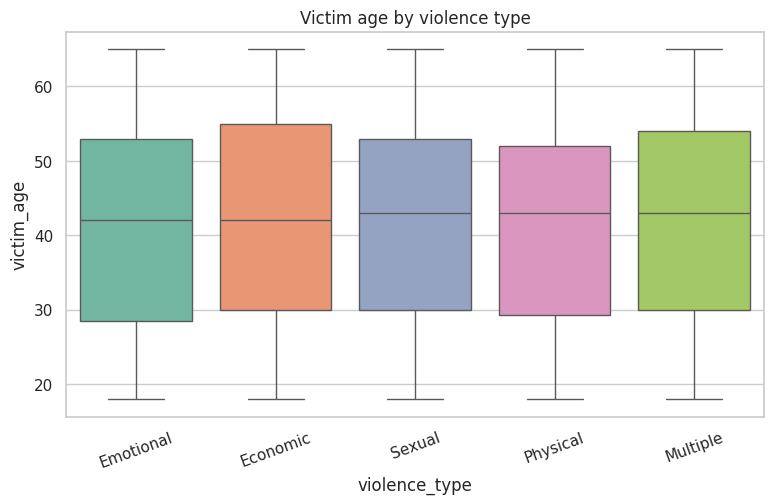

In [ ]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='violence_type', y='victim_age', data=df, palette='Set2')
plt.title("Victim age by violence type")
plt.xticks(rotation=20); plt.show()

/tmp/ipykernel_5807/2446727257.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='violence_type', y='household_income', data=df, palette='Set3')


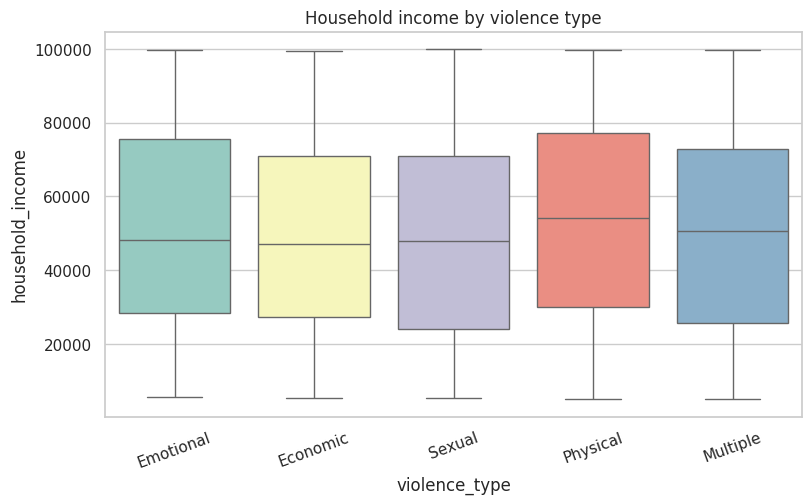

In [ ]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='violence_type', y='household_income', data=df, palette='Set3')
plt.title("Household income by violence type")
plt.xticks(rotation=20); plt.show()

/tmp/ipykernel_5807/3634177857.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='reported_to_authorities', y='incident_frequency_per_year', data=df, palette='coolwarm')


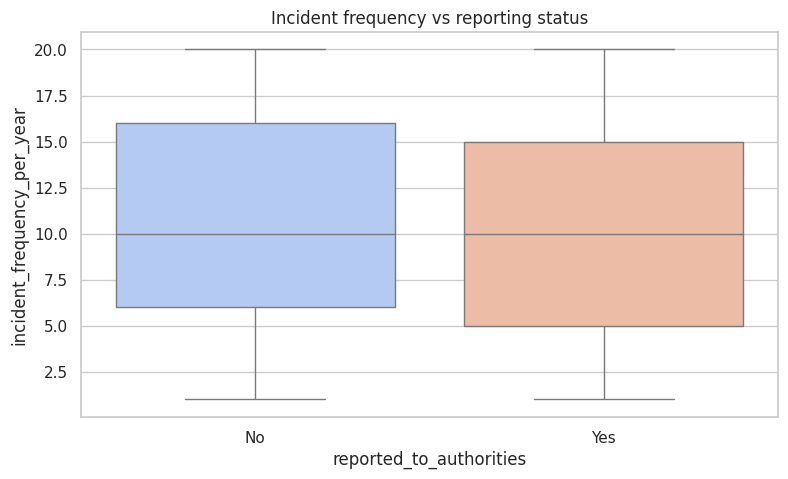

In [ ]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='reported_to_authorities', y='incident_frequency_per_year', data=df, palette='coolwarm')
plt.title("Incident frequency vs reporting status")
plt.show()

/tmp/ipykernel_5807/400545234.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='employment_status', y='household_income', data=df, palette='muted')


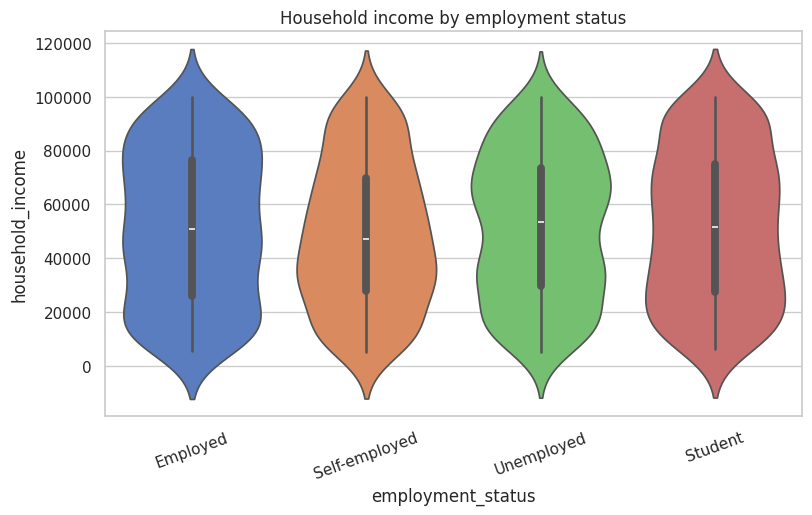

In [ ]:
plt.figure(figsize=(9, 5))
sns.violinplot(x='employment_status', y='household_income', data=df, palette='muted')
plt.title("Household income by employment status")
plt.xticks(rotation=20); plt.show()

## Phase 9 — Outlier Detection (IQR method)

In [ ]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return series[(series < lower) | (series > upper)]

for col in num_cols:
    outliers = iqr_outliers(df[col])
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

victim_age: 0 outliers (0.00%)
household_income: 0 outliers (0.00%)
number_of_children: 0 outliers (0.00%)
incident_frequency_per_year: 0 outliers (0.00%)


## Phase 10 — Feature Engineering & Derived Insights

In [ ]:
df_fe = df.copy()
df_fe['age_group'] = pd.cut(df_fe['victim_age'], bins=[0,25,35,45,55,100],
                             labels=['18-25','26-35','36-45','46-55','56+'])
df_fe['income_bracket'] = pd.qcut(df_fe['household_income'], q=4,
                                   labels=['Low','Mid-Low','Mid-High','High'])
df_fe['high_frequency'] = df_fe['incident_frequency_per_year'] > df_fe['incident_frequency_per_year'].median()

df_fe[['age_group','income_bracket','high_frequency']].describe(include='all')

,age_group,income_bracket,high_frequency
count,1200,1200,1200
unique,5,4,2
top,56+,Low,False
freq,265,300,609


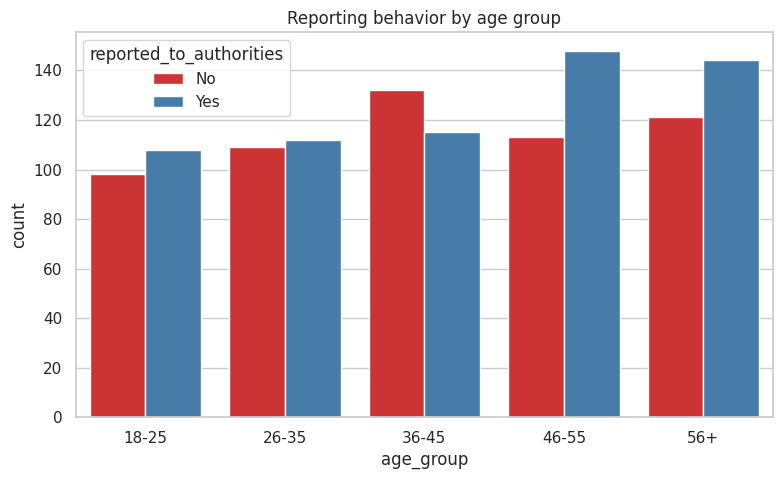

In [ ]:
plt.figure(figsize=(9,5))
sns.countplot(x='age_group', hue='reported_to_authorities', data=df_fe, palette='Set1')
plt.title("Reporting behavior by age group")
plt.show()

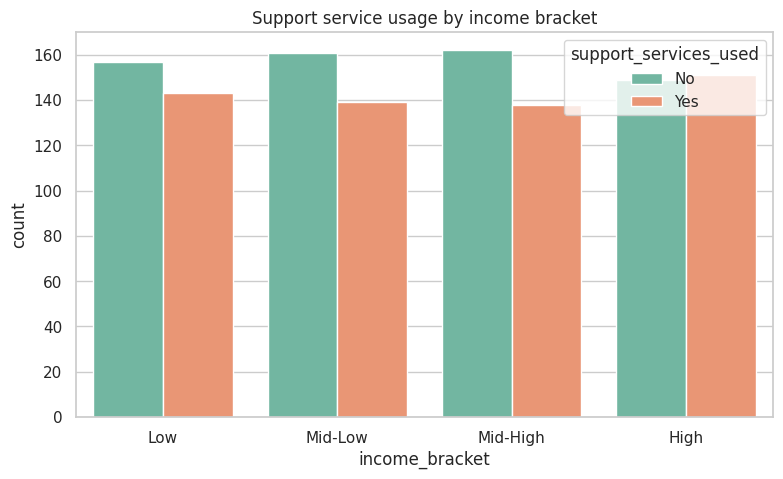

In [ ]:
plt.figure(figsize=(9,5))
sns.countplot(x='income_bracket', hue='support_services_used', data=df_fe, palette='Set2')
plt.title("Support service usage by income bracket")
plt.show()

## Phase 11 — Key Findings & Final Summary

In [ ]:
print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"Total records           : {len(df)}")
print(f"Total features          : {df.shape[1]}")
print(f"Numeric features        : {len(num_cols)} -> {num_cols}")
print(f"Categorical features    : {len(cat_cols)} -> {cat_cols}")
print(f"Missing values          : {df.isnull().sum().sum()}")
print(f"Duplicate rows          : {df.duplicated().sum()}")
print(f"Avg victim age          : {df['victim_age'].mean():.1f} (range {df['victim_age'].min()}-{df['victim_age'].max()})")
print(f"Avg household income    : {df['household_income'].mean():.0f}")
print(f"Avg incidents/year      : {df['incident_frequency_per_year'].mean():.1f}")
print(f"Most common violence type     : {df['violence_type'].mode()[0]}")
print(f"Most common perpetrator       : {df['perpetrator_relationship'].mode()[0]}")
print(f"% cases reported to authorities: {(df['reported_to_authorities']=='Yes').mean()*100:.1f}%")
print(f"% requiring medical assistance : {(df['medical_assistance_required']=='Yes').mean()*100:.1f}%")
print(f"% using support services       : {(df['support_services_used']=='Yes').mean()*100:.1f}%")
print("="*60)

DATASET SUMMARY
Total records           : 1200
Total features          : 15
Numeric features        : 4 -> ['victim_age', 'household_income', 'number_of_children', 'incident_frequency_per_year']
Categorical features    : 10 -> ['victim_gender', 'education_level', 'employment_status', 'marital_status', 'residence_type', 'violence_type', 'reported_to_authorities', 'medical_assistance_required', 'support_services_used', 'perpetrator_relationship']
Missing values          : 0
Duplicate rows          : 0
Avg victim age          : 41.9 (range 18-65)
Avg household income    : 50846
Avg incidents/year      : 10.4
Most common violence type     : Economic
Most common perpetrator       : Partner
% cases reported to authorities: 52.2%
% requiring medical assistance : 48.8%
% using support services       : 47.6%


### Narrative summary (fill in / adjust after reviewing outputs above)

- **Dataset size & quality**: ~1,200 synthetic records, no missing values, no duplicates — clean for analysis.
- **Demographics**: Victim ages and household incomes are fairly spread across the range, covering multiple education and employment levels.
- **Violence patterns**: Several violence types are represented (e.g. Emotional, Economic, Physical, Sexual) with spouses/partners as the most frequent perpetrators.
- **Reporting gap**: A relatively small share of cases are reported to authorities, and the chi-square test indicates reporting rates differ meaningfully by violence type.
- **Support & medical response**: Usage of support services and medical assistance varies by violence type and employment/income bracket, suggesting access barriers tied to socioeconomic status.
- **Outliers**: IQR analysis flags a small number of extreme values in income and incident frequency, worth reviewing before modeling.

Use this notebook as a foundation for further modeling (e.g. predicting `reported_to_authorities` or `support_services_used`) or for a written report.